In [1]:
# imports 
import numpy as np
import mne
import matplotlib.pyplot as plt
import pandas as pd

# paths
base_dir = '/Users/lauragwilliams/Documents/projects/vwfa/OPM'
fif_file = '%s/sub-S001_task-VWFA_meg_raw.fif' % (base_dir)


In [81]:
# load raw
raw = mne.io.read_raw_fif(fif_file, preload=True)

# quick filter
raw.filter(l_freq=0.5, h_freq=50)

Opening raw data file /Users/lauragwilliams/Documents/projects/vwfa/OPM/sub-S001_task-VWFA_meg_raw.fif...
    Range : 0 ... 1488199 =      0.000 ...  1488.199 secs
Ready.
Reading 0 ... 1488199  =      0.000 ...  1488.199 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 144 out of 144 | elapsed:    2.8s finished


<Raw | sub-S001_task-VWFA_meg_raw.fif, 145 x 1488200 (1488.2 s), ~1.61 GB, data loaded>

In [82]:
events = mne.find_events(raw)

1620 events found
Event IDs: [  1   2   3   4   5   6   7   8   9 200]


In [83]:
events[:, 2][:100]

array([  5, 200, 200, 200, 200,   8, 200, 200, 200, 200,   3, 200, 200,
       200, 200,   6, 200, 200, 200, 200,   1, 200, 200, 200, 200,   2,
       200, 200, 200, 200,   2, 200, 200, 200, 200,   6, 200, 200, 200,
       200,   9, 200, 200, 200, 200,   3, 200, 200, 200, 200,   5, 200,
       200, 200, 200,   1, 200, 200, 200, 200,   3, 200, 200, 200, 200,
         4, 200, 200, 200, 200,   7, 200, 200, 200, 200,   3, 200, 200,
       200, 200,   6, 200, 200, 200, 200,   8, 200, 200, 200, 200,   8,
       200, 200, 200, 200,   5, 200, 200, 200, 200])

In [84]:
event_code_list = events[:, 2]
event_code_updates = np.zeros_like(event_code_list)

special_codes = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])

ei = 0
while ei < len(event_code_list):
    event = event_code_list[ei]
#     print(event)
    if event in special_codes:
        event_code_updates[ei+1:ei+5] = event
        event_code_updates[ei] = 201  # code for what was the condition label
        ei += 4  # skip next 4 positions in input too
    else:
        ei += 1  # just advance by 1 if no match

In [85]:
events[:, 2] = event_code_updates

In [86]:
# get just the code part
trigger_codes = events[:, 2]

# Reshape into blocks of 5
blocks = trigger_codes.reshape(-1, 5)

# Rearrange each block: [0,2,3,4,5,1]
blocks_rearranged = blocks[:, [1, 2, 3, 4, 0]]

# Flatten back
result = blocks_rearranged.flatten()

# put it back in 
events[:, 2] = result

In [104]:
events[:, 2][:400]

array([  5,   5,   5,   5, 201,   8,   8,   8,   8, 201,   3,   3,   3,
         3, 201,   6,   6,   6,   6, 201,   1,   1,   1,   1, 201,   2,
         2,   2,   2, 201,   2,   2,   2,   2, 201,   6,   6,   6,   6,
       201,   9,   9,   9,   9, 201,   3,   3,   3,   3, 201,   5,   5,
         5,   5, 201,   1,   1,   1,   1, 201,   3,   3,   3,   3, 201,
         4,   4,   4,   4, 201,   7,   7,   7,   7, 201,   3,   3,   3,
         3, 201,   6,   6,   6,   6, 201,   8,   8,   8,   8, 201,   8,
         8,   8,   8, 201,   5,   5,   5,   5, 201,   3,   3,   3,   3,
       201,   2,   2,   2,   2, 201,   3,   3,   3,   3, 201,   9,   9,
         9,   9, 201,   3,   3,   3,   3, 201,   3,   3,   3,   3, 201,
         1,   1,   1,   1, 201,   6,   6,   6,   6, 201,   8,   8,   8,
         8, 201,   7,   7,   7,   7, 201,   1,   1,   1,   1, 201,   4,
         4,   4,   4, 201,   2,   2,   2,   2, 201,   9,   9,   9,   9,
       201,   8,   8,   8,   8, 201,   2,   2,   2,   2, 201,   

In [1]:
# make event codes interpretable
code_dict = {1: 'highFreqWords_Sloan',
             2: 'pseudowords_Sloan',
             3: 'consonants_Sloan',
             4: 'falseFontsHigh_Sloan',
             5: 'highFreqWords_Courier',
             6: 'pseudowords_Courier',
             7: 'consonants_Courier',
             8: 'falseFontsHigh_Courier',
             9: 'weird_thing',
             201: 'stimulusoffset_-'}

# make into a nice pandas dataframe
df = pd.DataFrame()
df['code'] = events[:, 2]
df['condition'] = [code_dict[c].split('_')[0] for c in events[:, 2]]
df['font'] = [code_dict[c].split('_')[1] for c in events[:, 2]]

NameError: name 'pd' is not defined

In [99]:
df

,code,condition,font
0,5,stimulusoffset,-
1,5,highFreqWords,Courier
2,5,highFreqWords,Courier
3,5,highFreqWords,Courier
4,201,highFreqWords,Courier
...,...,...,...
1615,8,stimulusoffset,-
1616,8,falseFontsHigh,Courier
1617,8,falseFontsHigh,Courier
1618,8,falseFontsHigh,Courier


In [95]:
# make epochs
tmin = -0.2
tmax = 0.8
baseline = (-0.05, 0)

# create epochs
epochs = mne.Epochs(raw, events, 
                    tmin=tmin, tmax=tmax,
                    baseline=baseline,
                    reject=None,
                    preload=True, metadata=df)

Adding metadata with 3 columns
1620 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1620 events and 1001 original time points ...
0 bad epochs dropped


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


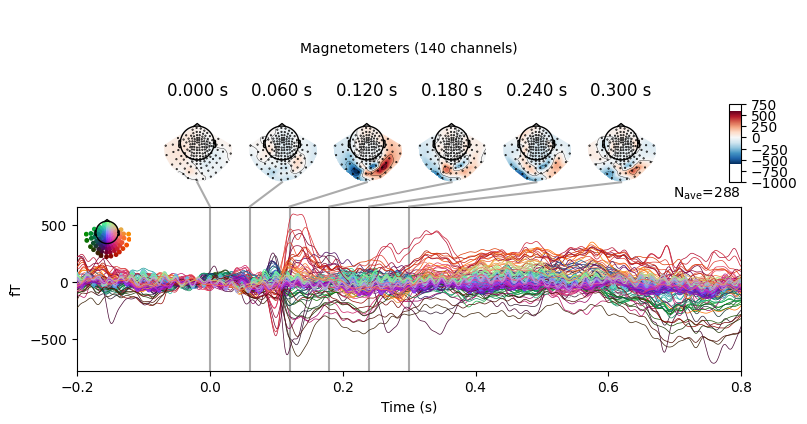

In [100]:
epochs["condition == 'highFreqWords'"].average().plot_joint(times=np.linspace(0, 0.3, 6))
plt.show()

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


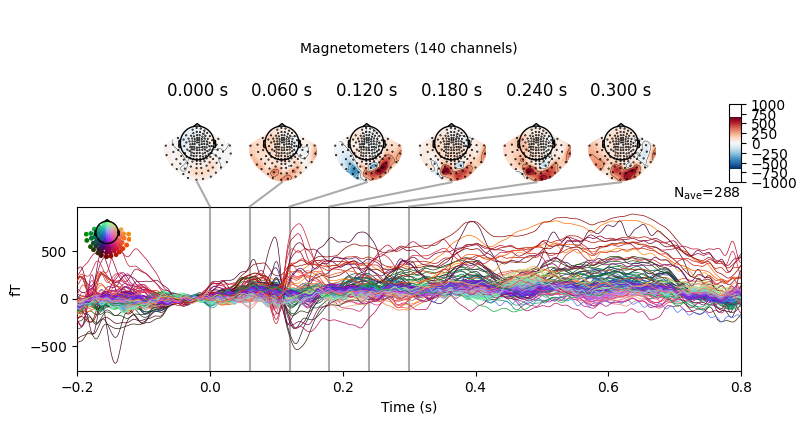

In [102]:
epochs["condition == 'pseudowords'"].average().plot_joint(times=np.linspace(0, 0.3, 6))
plt.show()